# Task 3: Instance Segmentation of Plants
This notebook implements a traditional computer vision approach to segment individual plants in given Petri dish images. Unlike semantic segmentation, which treats all similar objects as one, instance segmentation isolates each plant as a distinct object.

## Requirements:
- Use only traditional CV techniques (no ML or DL).
- Identify five distinct plant instances.
- Final output must resemble Figure 3.1 from the Creative Brief.
- Process at least task_3_image_1.png and task_3_image_2.png.

In [40]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


## Step 1: Preprocessing - Crop the Petri Dish (Reusing Task 2 Code)

Before segmenting the plants, we first need to isolate the Petri dish area from the full image.
To maintain consistency, we reuse the Petri dish detection and cropping function from Task 2. This function performs the following operations:
- Converts the image to grayscale.
- Detects and removes any white legend on the right (specific to Y2B_23 images).
- Applies Gaussian blur to reduce noise.
- Uses Otsu’s thresholding and contour detection to locate the Petri dish.
- Crops and returns a square region containing the Petri dish.

This ensures that the plant segmentation steps operate only on the relevant region of the image.

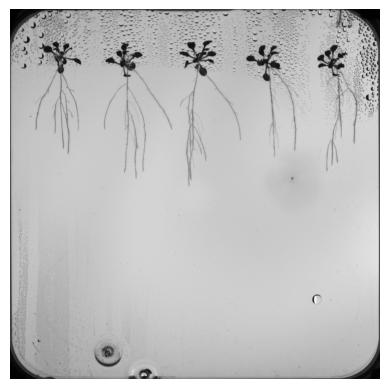

In [41]:
def process_and_crop_image(image_path):
    # Load and convert to grayscale
    image = cv2.imread(image_path, 0)
    height, width = image.shape

    # Check the right-side columns for a bright legend
    right_columns = image[:, -20:]
    mean_intensity = np.mean(right_columns)
    
    # Threshold to decide if a legend exists
    threshold = 200 
    if mean_intensity > threshold:
        image_cropped = image[:, :-100]  # Remove ~100 pixels from the right
    else:
        image_cropped = image
    
    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(image_cropped, (11, 11), 0)
    
    # Otsu Thresholding
    _, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(otsu_thresh, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)
    
    # Identify the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get bounding box around the largest contour and ensure square
    x, y, w, h = cv2.boundingRect(largest_contour)
    size = max(w, h)
    x_center = x + w // 2
    y_center = y + h // 2
    x_start = max(0, x_center - size // 2)
    y_start = max(0, y_center - size // 2)
    
    # Crop the image
    cropped_image = image_cropped[y_start:y_start+size, x_start:x_start+size]
    
    # Return the cropped image
    return cropped_image

# Load and process the uploaded image
image_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task3\task_3_image_2.png"
cropped_image = process_and_crop_image(image_path)

# Display the cropped image
plt.imshow(cropped_image, cmap='gray')
plt.axis('off')
plt.show()

# **Approach 1: Adaptive Thresholding + Morphology + Connected Components** 
In this approach, we segment individual plants using a combination of **adaptive thresholding**, **morphological operations**, and **connected component analysis**.

#### Key steps in this pipeline:
1. Apply **adaptive thresholding** to highlight plant regions while adapting to varying lighting conditions.
2. Use **morphological closing** to remove small holes and noise in the binary mask.
3. Create and apply an **edge mask** to remove artifacts from the Petri dish border.
4. **Invert** the binary mask so plant regions appear white (foreground) for analysis.
5. Use **connected component analysis** to label distinct plant regions.
6. Filter out small noise components, keeping only the most prominent ones (i.e., the five largest plants).

### **Step 1: Apply Gaussian Blur to Reduce Noise**

Before thresholding, we apply a **Gaussian blur** to the cropped grayscale image. This helps reduce minor variations in pixel intensity and smoothes the image, which is essential for more consistent thresholding results in the next step. The kernel size `(3, 3)` is chosen to lightly smooth the image while preserving edge information.

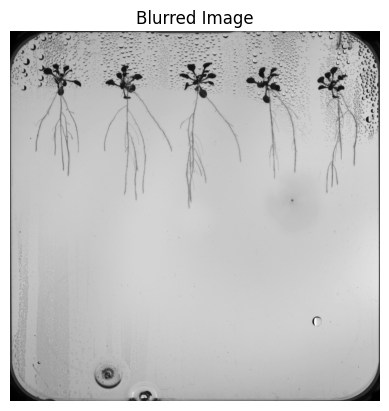

In [42]:
# Assume cropped_image is already available from previous steps
blurred_image = cv2.GaussianBlur(cropped_image, (3, 3), 0)

# Display the blurred image
plt.imshow(blurred_image, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')
plt.show()

### **Step 2: Adaptive Thresholding**

We apply **adaptive thresholding** to the cropped and blurred grayscale image. This method determines thresholds based on local pixel neighborhoods, making it ideal for images with varying lighting. The result is a binary image where potential plant areas are highlighted.


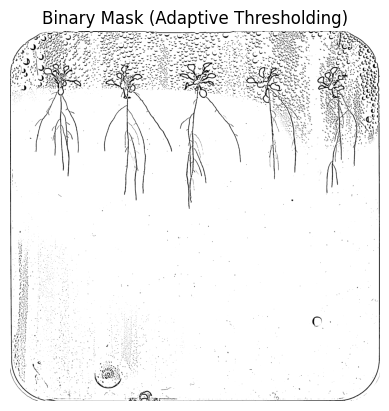

In [43]:
# Apply Adaptive Thresholding
binary_mask = cv2.adaptiveThreshold(
    blurred_image,  # Input image (grayscale)
    255,            # Maximum value for binary output
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # Adaptive thresholding method
    cv2.THRESH_BINARY,               # Type of thresholding
    21,              # Block size (size of the neighborhood)
    7               # Constant subtracted from the mean
)

# Display the binary mask after adaptive thresholding
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask (Adaptive Thresholding)")
plt.axis('off')
plt.show()

### **Step 3: Morphological Closing** 

To remove noise and small gaps in the thresholded image, we perform a **morphological closing operation** using an elliptical kernel. This helps in joining fragmented regions that belong to the same plant.


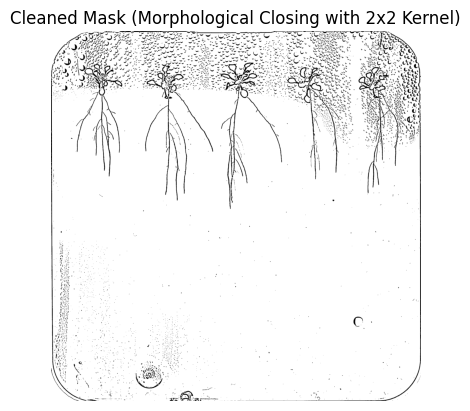

In [44]:
# Define a kernel for the morphological operation
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
# Perform morphological closing
cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

# Display the cleaned mask after morphological closing
plt.imshow(cleaned_mask, cmap='gray')
plt.title("Cleaned Mask (Morphological Closing with 2x2 Kernel)")
plt.axis('off')
plt.show()

### **Step 4: Removing Edge Artifacts** 

Since the Petri dish edges might falsely appear as large contours, we mask out all edges of the image (top, bottom, left, right) using rectangles. This ensures only the internal regions (i.e., plants) are preserved for segmentation.


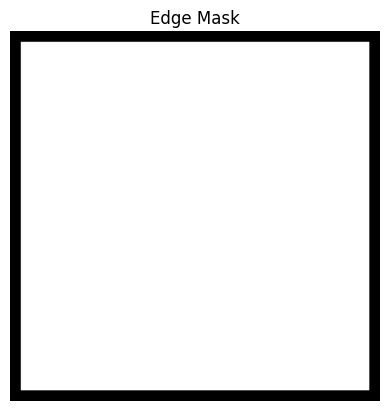

In [45]:
# Step 4: Create a mask to remove edges
height, width = cleaned_mask.shape
edge_thickness = 80  # Thickness of the edge to mask
mask = np.ones((height, width), dtype=np.uint8) * 255
cv2.rectangle(mask, (0, 0), (width, edge_thickness), 0, -1)  # Top edge
cv2.rectangle(mask, (0, 0), (edge_thickness, height), 0, -1)  # Left edge
cv2.rectangle(mask, (0, height - edge_thickness), (width, height), 0, -1)  # Bottom edge
cv2.rectangle(mask, (width - edge_thickness, 0), (width, height), 0, -1)  # Right edge

# Display the mask
plt.imshow(mask, cmap='gray')
plt.title("Edge Mask")
plt.axis('off')
plt.show()

### **Step 5: Apply Edge Mask**

We apply the previously created edge mask to the cleaned binary image using bitwise operations. This step removes the outer border pixels and focuses segmentation only within the usable dish area.


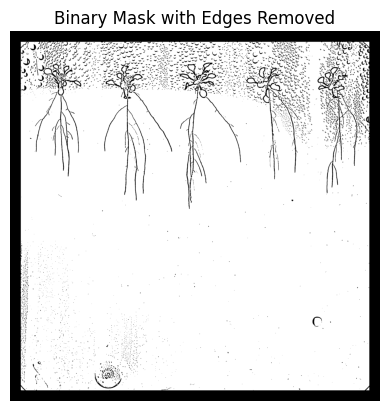

In [46]:
# Step 5: Apply the mask to the cleaned binary mask
masked_binary = cv2.bitwise_and(cleaned_mask, cleaned_mask, mask=mask)

# Display the masked binary image
plt.imshow(masked_binary, cmap='gray')
plt.title("Binary Mask with Edges Removed")
plt.axis('off')
plt.show()

### **Step 6: Invert Binary Mask**

The adaptive thresholding step often produces white backgrounds and black plants. We invert the mask to ensure plants appear white (foreground) and background black—this is required for accurate connected component analysis.

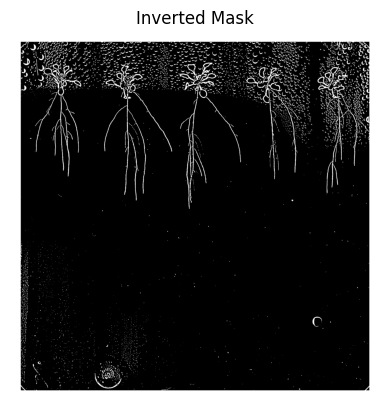

In [47]:
# Invert the binary mask
inverted_mask = cv2.bitwise_not(masked_binary)

# Display the inverted mask
plt.imshow(inverted_mask, cmap='gray')
plt.title("Inverted Mask")
plt.axis('off')
plt.show()

### **Step 7: Connected Component Analysis**

We use **`cv2.connectedComponentsWithStats()`** to label all connected white regions in the inverted binary mask. Each label corresponds to a potential plant. The stats include pixel area and centroid location for each label, which we use later to filter and visualize only the largest components.

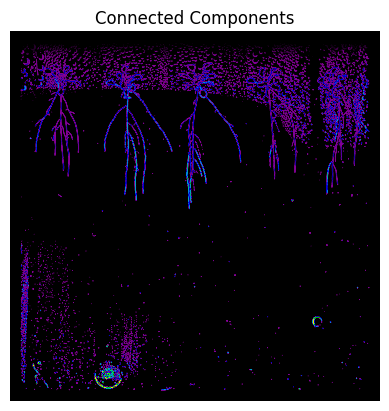

Number of connected components (including background): 4210


In [48]:
# Find connected components with stats
num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(inverted_mask)

# Display the labeled image
plt.imshow(labels_im, cmap='nipy_spectral')
plt.title("Connected Components")
plt.axis('off')
plt.show()

print(f"Number of connected components (including background): {num_labels}")


### **Step 8: Filter and Visualize the Largest Plant Components**

To isolate only the actual plants and remove noise or small fragments, we filter out components based on their **pixel area**. We use a minimum size threshold (800 pixels) to exclude insignificant regions.

- We initialize an empty label mask (`int32` type to prevent overflow).
- Components meeting the size requirement are preserved.
- Finally, we normalize the labels and visualize the remaining regions using a colormap. This visualization shows the distinct segmented plant instances.

This step effectively narrows down our connected components to the **most prominent plant regions**.

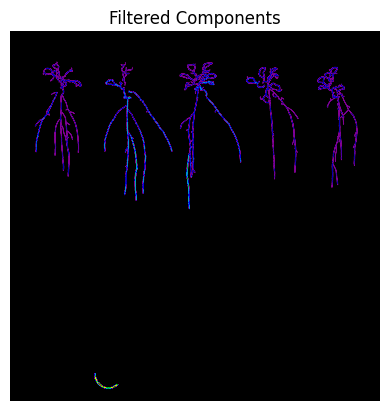

In [49]:
# Use a larger data type to avoid overflow warnings
filtered_labels = np.zeros_like(labels_im, dtype=np.int32)  # Change dtype to int32

min_size = 1700  # Minimum size of a plant component in pixels
for label in range(1, num_labels):  # Skip label 0 (background)
    component_mask = (labels_im == label)
    if np.sum(component_mask) > min_size:
        filtered_labels[component_mask] = label

# Normalize the labels
visualization_labels = (filtered_labels * 255 // np.max(filtered_labels)).astype(np.uint8)

# Display the visualization labels
plt.imshow(visualization_labels, cmap='nipy_spectral')
plt.title("Filtered Components")
plt.axis('off')
plt.show()

# **Approach 2: Otsu Thresholding + Aspect Ratio Filtering**

This approach performs instance segmentation using global thresholding and geometric heuristics. The focus is on identifying vertical plant-like shapes using bounding box and aspect ratio analysis.

### **Summary of Steps:**
1. Crop the Petri dish region using the function developed in Task 2.
2. Apply Otsu's thresholding to create a binary mask.
3. Use connected component analysis to identify distinct regions.
4. Filter regions based on bounding box area and aspect ratio.
5. Select the top 5 plant candidates and visualize the segmentation.


### **Step 1: Preprocessing and Cropping (Reused from Task 2)**

We reuse the same cropping function from Task 2 to detect and isolate the Petri dish. This ensures we focus only on the region of interest and exclude background noise or legends from Y2B_23 images.


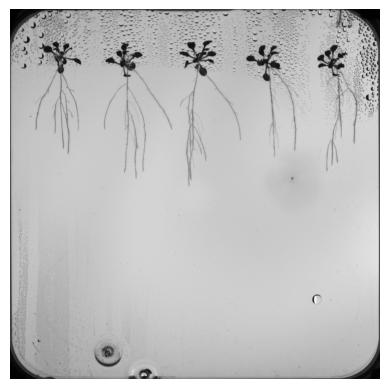

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_crop_image(image_path):
    # Load and convert to grayscale
    image = cv2.imread(image_path, 0)
    height, width = image.shape

    # Check the right-side columns for a bright legend
    right_columns = image[:, -20:]
    mean_intensity = np.mean(right_columns)
    
    # Threshold to decide if a legend exists
    threshold = 200 
    if mean_intensity > threshold:
        image_cropped = image[:, :-100]  # Remove ~100 pixels from the right
    else:
        image_cropped = image
    
    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(image_cropped, (11, 11), 0)
    
    # Otsu Thresholding
    _, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(otsu_thresh, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)
    
    # Identify the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get bounding box around the largest contour and ensure square
    x, y, w, h = cv2.boundingRect(largest_contour)
    size = max(w, h)
    x_center = x + w // 2
    y_center = y + h // 2
    x_start = max(0, x_center - size // 2)
    y_start = max(0, y_center - size // 2)
    
    # Crop the image
    cropped_image = image_cropped[y_start:y_start+size, x_start:x_start+size]
    
    # Return the cropped image
    return cropped_image

# Load and process the uploaded image
image_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task3\task_3_image_2.png"
cropped_image = process_and_crop_image(image_path)

# Display the cropped image
plt.imshow(cropped_image, cmap='gray')
plt.axis('off')
plt.show()

### **Step 2: Apply Otsu’s Thresholding**

We apply Otsu’s thresholding to convert the grayscale image to binary. A manually selected threshold value of 164 is used to produce a clean foreground-background separation, with plant areas appearing white on a black background.


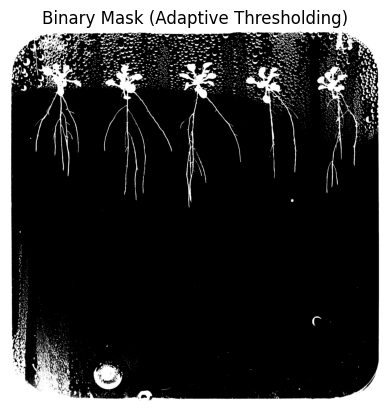

In [51]:
_, binary_image = cv2.threshold(cropped_image, 164, 255, cv2.THRESH_BINARY_INV)

# Display the binary mask after adaptive thresholding
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Mask (Adaptive Thresholding)")
plt.axis('off')
plt.show()

### **Step 3: Connected Component Analysis**

We use **`cv2.connectedComponentsWithStats()`** to identify all connected regions in the binary mask. Each connected component is assigned a unique label, and statistics such as bounding box and area are calculated. These stats are used in the following step for filtering.


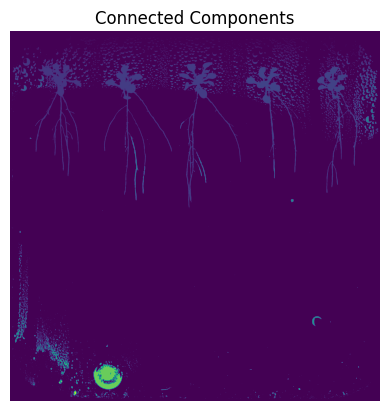

Number of connected components (including background): 4978


In [52]:
# Find connected components with stats
num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(binary_image)

# Display the labeled image
plt.imshow(labels_im)
plt.title("Connected Components")
plt.axis('off')
plt.show()

print(f"Number of connected components (including background): {num_labels}")

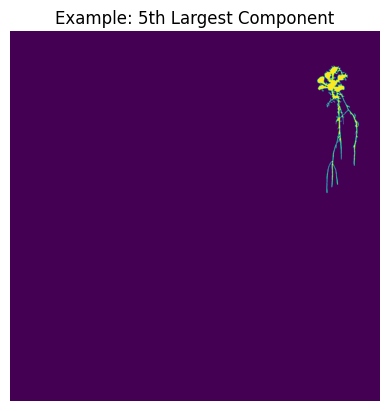

In [53]:
# Optional check: View the 5th largest component visually
cc_id = np.argsort(stats[:, -1])[-5]
plt.imshow(labels_im == cc_id)
plt.title("Example: 5th Largest Component")
plt.axis('off')
plt.show()

### **Step 4: Bounding Box and Aspect Ratio Filtering**

To isolate potential plant shapes, we filter the connected components based on two criteria:

- **Bounding box area**: We assume larger bounding boxes are more likely to correspond to full plants.
- **Aspect ratio**: Since plants tend to grow vertically, we only keep components where the height is at least 1.5 times the width.

We calculate the bounding box area for each component, sort them in descending order, and select the top 5 components that satisfy the vertical aspect ratio condition. These are stored in `top_5_labels` for further processing.


In [ ]:
# Define aspect ratio threshold for vertical rectangles
aspect_ratio_threshold = 1.5  # Vertical rectangles will have AR > 1

# Calculate the bounding box area for each component
bounding_box_areas = [(stats[i][2] * stats[i][3], i) for i in range(1, num_labels)]  # (w * h, label)
bounding_box_areas_sorted = sorted(bounding_box_areas, key=lambda x: x[0], reverse=True)  # Sort by bounding box area

# Filter out components based on aspect ratio and keep only the top 5 with largest bounding box area
top_5_labels = []
for _, label in bounding_box_areas_sorted:
    x, y, w, h, _ = stats[label]
    aspect_ratio = h / w if w > 0 else 0  # Prevent division by zero
    if aspect_ratio > aspect_ratio_threshold:  # Check if it is a vertical rectangle
        top_5_labels.append(label)
    if len(top_5_labels) == 5:  # Stop once we have 5 components
        break

# Print selected labels
print("Top 5 selected labels:", top_5_labels)

Top 5 selected labels: [893, 882, 997, 780, 988]


### **Step 5: Generate Final Labeled Output**

We initialize an empty output array and assign a unique label (from 1 to 5) to each of the selected plant components from `top_5_labels`. This results in a labeled segmentation mask where each detected plant is visualized with a distinct color using the default colormap.

The visualization allows us to clearly differentiate between the individual plant instances identified through filtering.


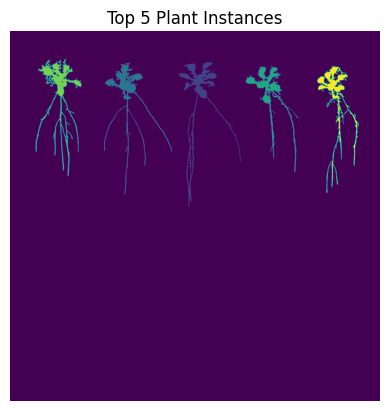

In [60]:
# Initialize an empty output array with the same shape as the label image
output = np.zeros_like(labels_im, dtype=np.uint8)

# Assign a unique integer label (1 to 5) to each selected plant component
counter = 1
for cc_id in top_5_labels:
    output[labels_im == cc_id] = counter
    counter += 1

# Display the final labeled output
plt.imshow(output)
plt.title("Top 5 Plant Instances")
plt.axis('off')
plt.show()


## Final Pipeline

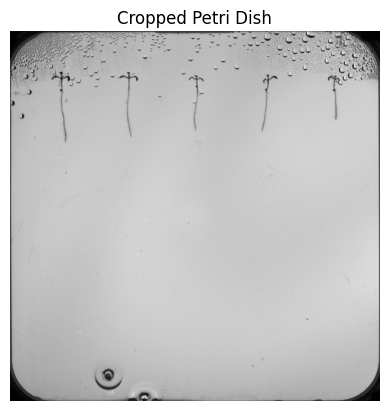

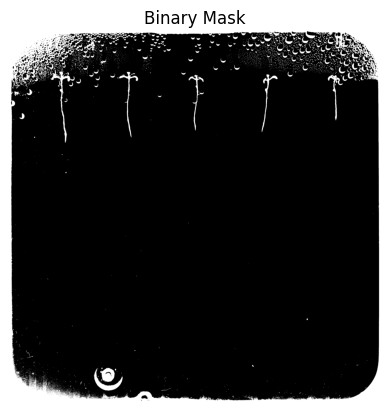

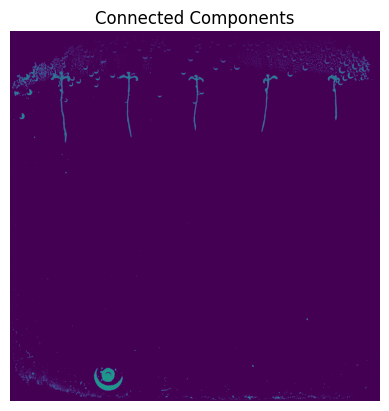

Number of connected components (including background): 5344
Top 5 selected labels: [2079, 2204, 2287, 2299, 2295]


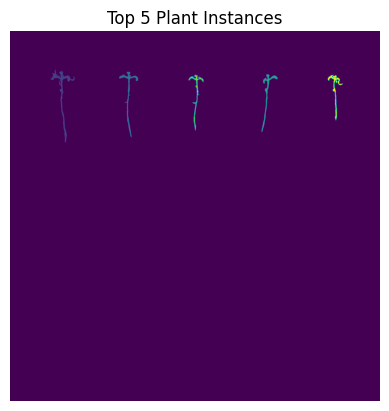

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_crop_image(image_path):
    # Load the image in grayscale
    image = cv2.imread(image_path, 0)
    height, width = image.shape

    # Check if a bright legend exists on the right side (Y2B_23 images)
    right_columns = image[:, -20:]
    mean_intensity = np.mean(right_columns)
    
    # Crop out the legend if present
    threshold = 200
    if mean_intensity > threshold:
        image_cropped = image[:, :-100]
    else:
        image_cropped = image

    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(image_cropped, (11, 11), 0)

    # Apply Otsu’s thresholding to binarize the image
    _, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Detect contours and isolate the largest one (assumed to be the Petri dish)
    contours, _ = cv2.findContours(otsu_thresh, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)

    # Create a square crop around the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    size = max(w, h)
    x_center = x + w // 2
    y_center = y + h // 2
    x_start = max(0, x_center - size // 2)
    y_start = max(0, y_center - size // 2)
    cropped_image = image_cropped[y_start:y_start+size, x_start:x_start+size]

    return cropped_image

# Load and preprocess the image
image_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25b-fai2-adsai-ViktoriaKubisova231781\datalab_tasks\task3\task_3_image_1.png"
cropped_image = process_and_crop_image(image_path)

# Display the cropped Petri dish
plt.imshow(cropped_image, cmap='gray')
plt.axis('off')
plt.title("Cropped Petri Dish")
plt.show()

# Step 2: Apply Otsu's Thresholding (manual value used here for better segmentation)
_, binary_image = cv2.threshold(cropped_image, 164, 255, cv2.THRESH_BINARY_INV)

# Display the binary mask
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Mask")
plt.axis('off')
plt.show()

# Step 3: Connected Component Analysis
num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(binary_image)

# Display connected components
plt.imshow(labels_im)
plt.title("Connected Components")
plt.axis('off')
plt.show()

print(f"Number of connected components (including background): {num_labels}")


# Step 4: Bounding Box and Aspect Ratio Filtering
aspect_ratio_threshold = 1.5  # Plants are expected to be vertically elongated

# Calculate bounding box areas and sort them
bounding_box_areas = [(stats[i][2] * stats[i][3], i) for i in range(1, num_labels)]
bounding_box_areas_sorted = sorted(bounding_box_areas, key=lambda x: x[0], reverse=True)

# Select top 5 labels with vertical aspect ratio
top_5_labels = []
for _, label in bounding_box_areas_sorted:
    x, y, w, h, _ = stats[label]
    aspect_ratio = h / w if w > 0 else 0
    if aspect_ratio > aspect_ratio_threshold:
        top_5_labels.append(label)
    if len(top_5_labels) == 5:
        break

print("Top 5 selected labels:", top_5_labels)

# Step 5: Generate Final Labeled Output
output = np.zeros_like(labels_im, dtype=np.uint8)

# Assign unique labels (1–5) to each selected component
counter = 1
for cc_id in top_5_labels:
    output[labels_im == cc_id] = counter
    counter += 1

# Display the final labeled segmentation
plt.imshow(output)
plt.title("Top 5 Plant Instances")
plt.axis('off')
plt.show()